# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 4: *Variable Selection*
##### Version Number: 2.0
---
### Contents  
> 1. *Water Demand*
> 2. *Water Supply*
> 3. *Water Supply Indexes*
> 4. *Fire Danger Indicators*
> 5. *Social Variables*
> 6. *Temporal and Geographic Varaibles*
> 7. *Export File*
---
### Notes
- This module visualizes key environmental variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and influence fire risk.
---
### Inputs
- `model_fire_pop_income.csv` cleaned weather data joined with cleaned fire damage dataset
- `details.csv` saved details associated with main dataset
---
### Outputs 
- `trimmed.csv` - trimmed weather and fire dataset
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

# Function to print a custom format correlation heatmap
from src.plot_utils import bar_group

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

### Loading Data

In [3]:
filtered = pd.read_csv('../data/processed/samples_income.csv')

---

## 1. DIrect Water Demand Indicators

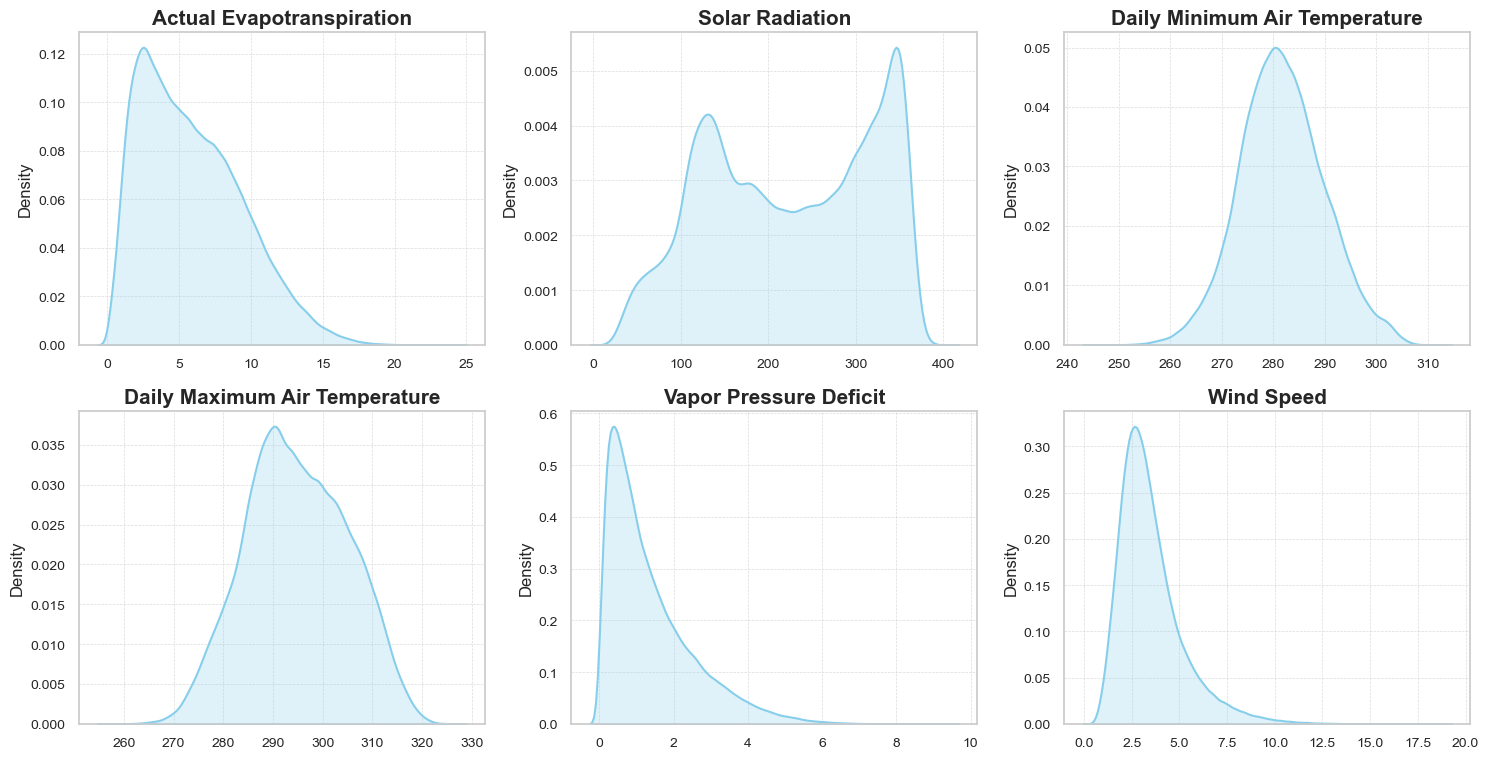

In [5]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    "Wind Speed",
    "Target"
]


grid_kde(filtered[water_demand].drop(columns='Target'))

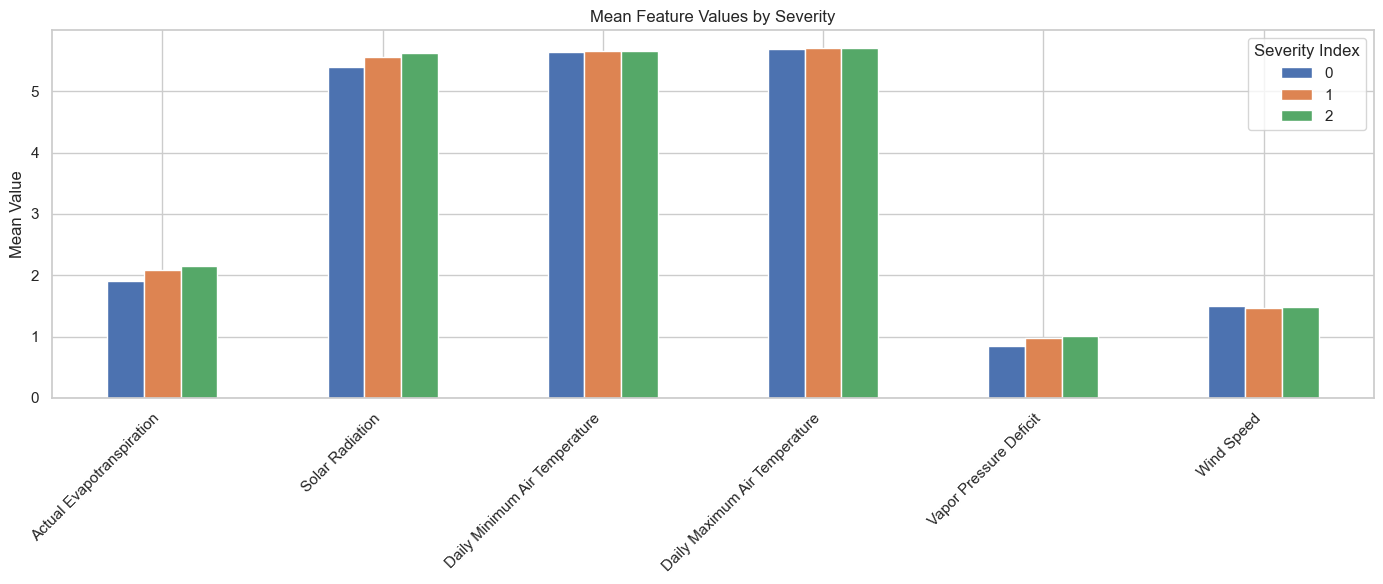

In [6]:
bar_group(filtered[water_demand])

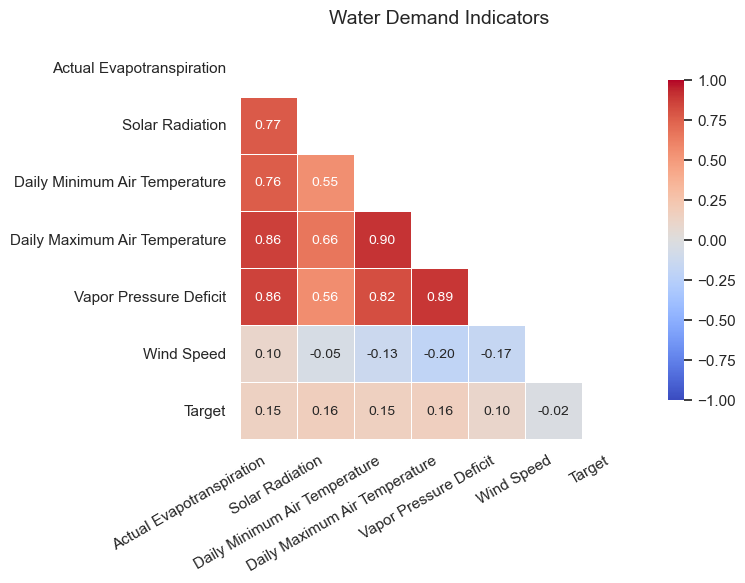

In [7]:
correlation_map(filtered[water_demand],'Water Demand Indicators')

---

## 3. Water Supply Indicators

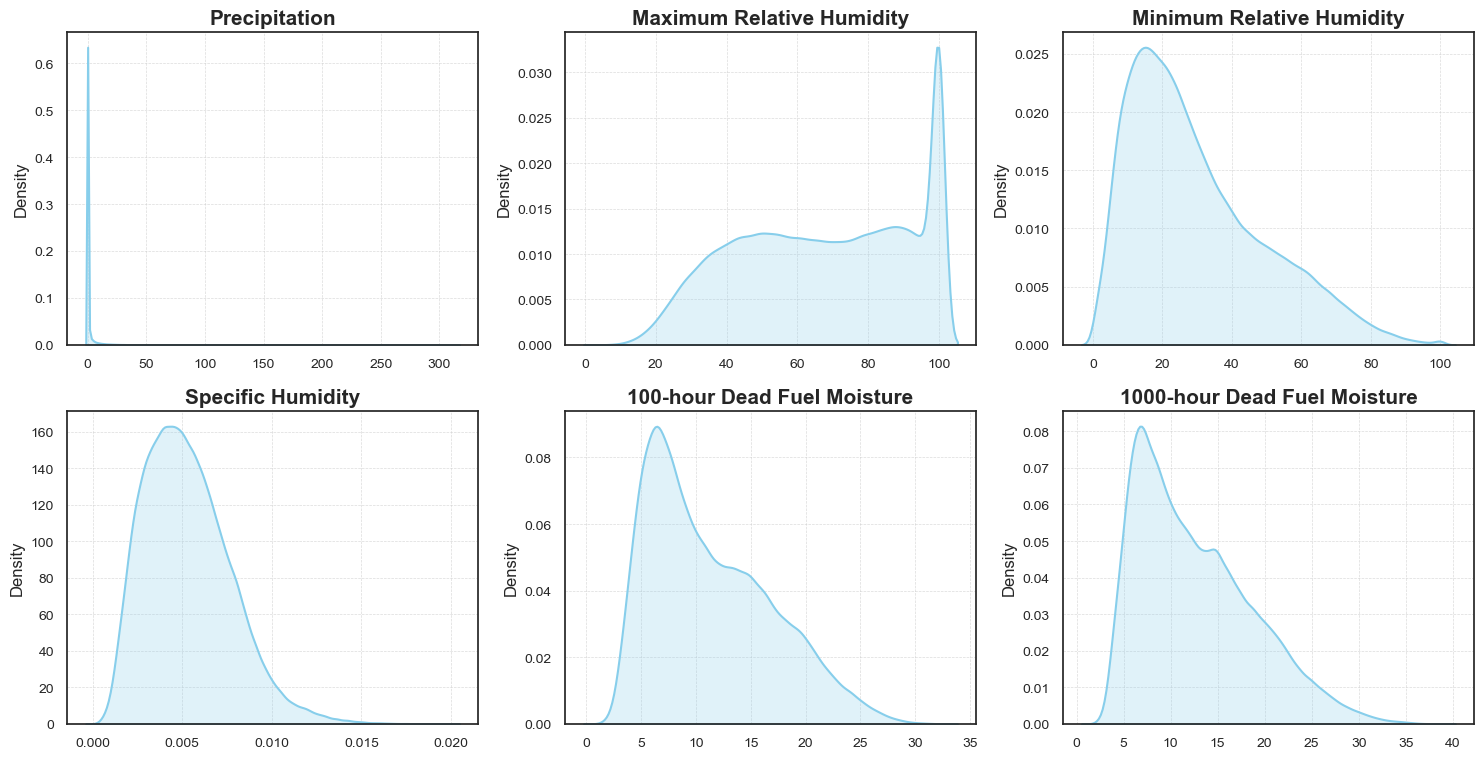

In [9]:
water_supply = [
    "Precipitation",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture",
    'Target'
]

grid_kde(filtered[water_supply].drop(columns='Target'))

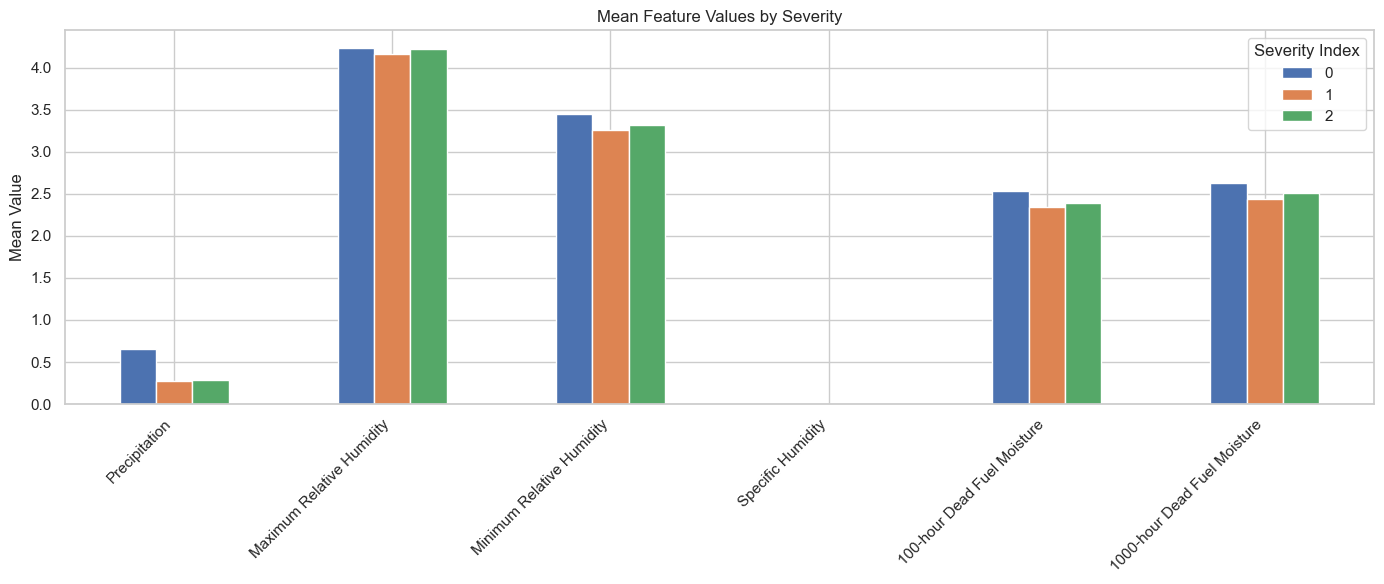

In [11]:
bar_group(filtered[water_supply])

### 3.2 Water Supply Correlation Analysis

- **Inverse Relationship with Fire Severity**  
  Both precipitation and relative humidity indicators are **negatively correlated** with the categorical fire risk index. This aligns with domain expectations—**drier and less humid conditions correspond to higher wildfire severity**.

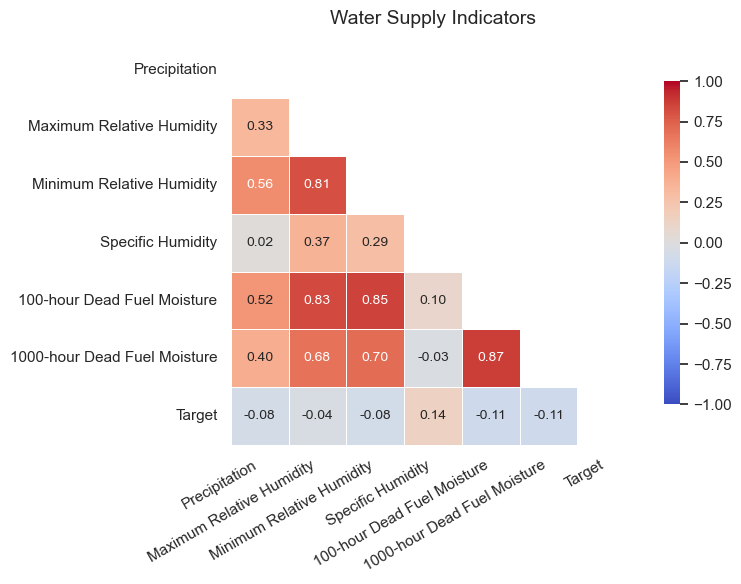

In [12]:
correlation_map(filtered[water_supply],'Water Supply Indicators')

---

## 4. Water Supply Indexes

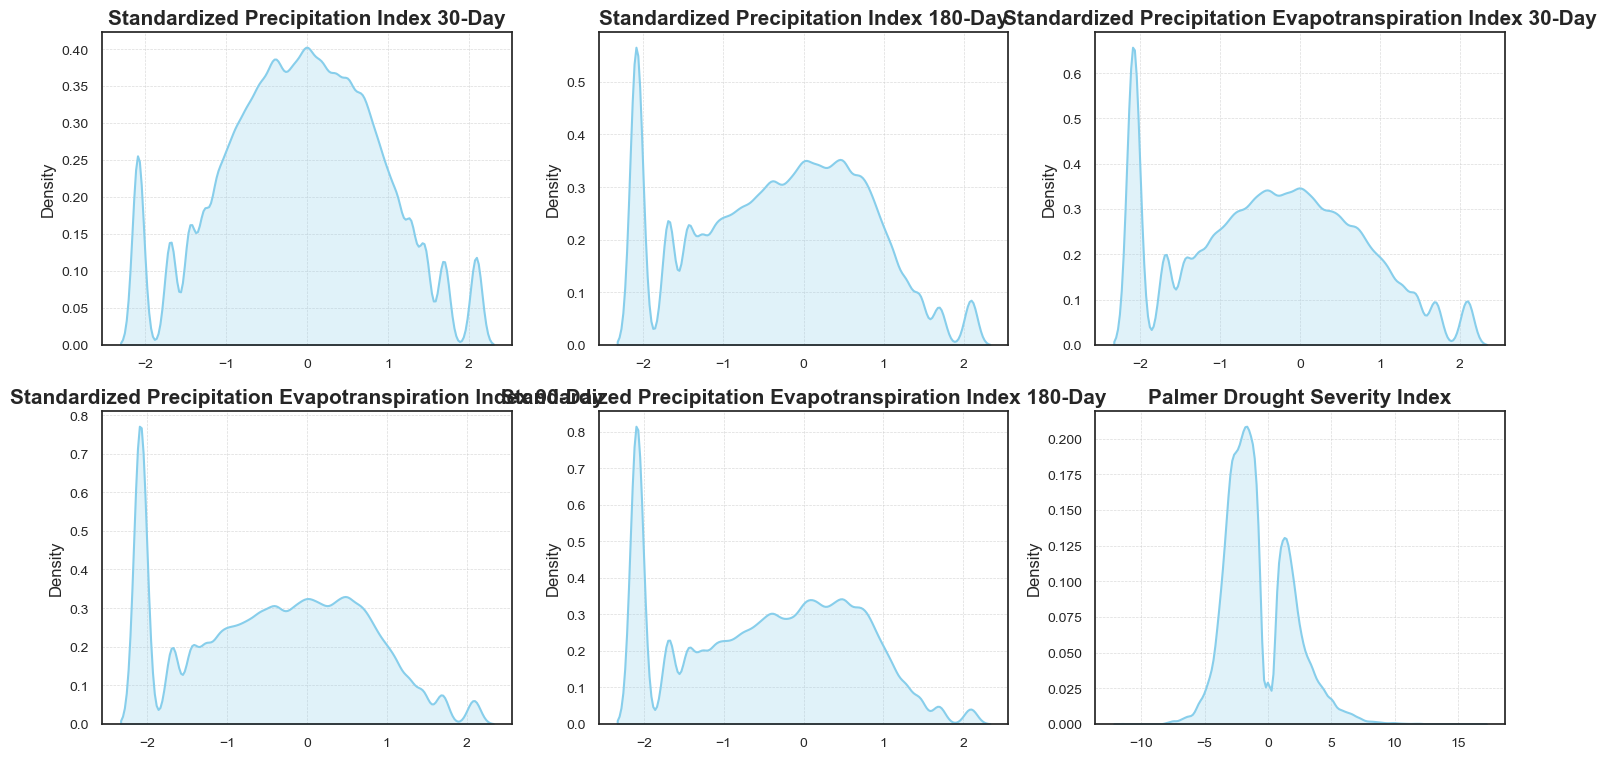

In [13]:
water_supply_indexes = ["Standardized Precipitation Index 30-Day",
    "Standardized Precipitation Index 180-Day",
    "Standardized Precipitation Evapotranspiration Index 30-Day",
    "Standardized Precipitation Evapotranspiration Index 90-Day",
    "Standardized Precipitation Evapotranspiration Index 180-Day",
    "Palmer Drought Severity Index",
                       'Target']
grid_kde(filtered[water_supply_indexes].drop(columns='Target'))

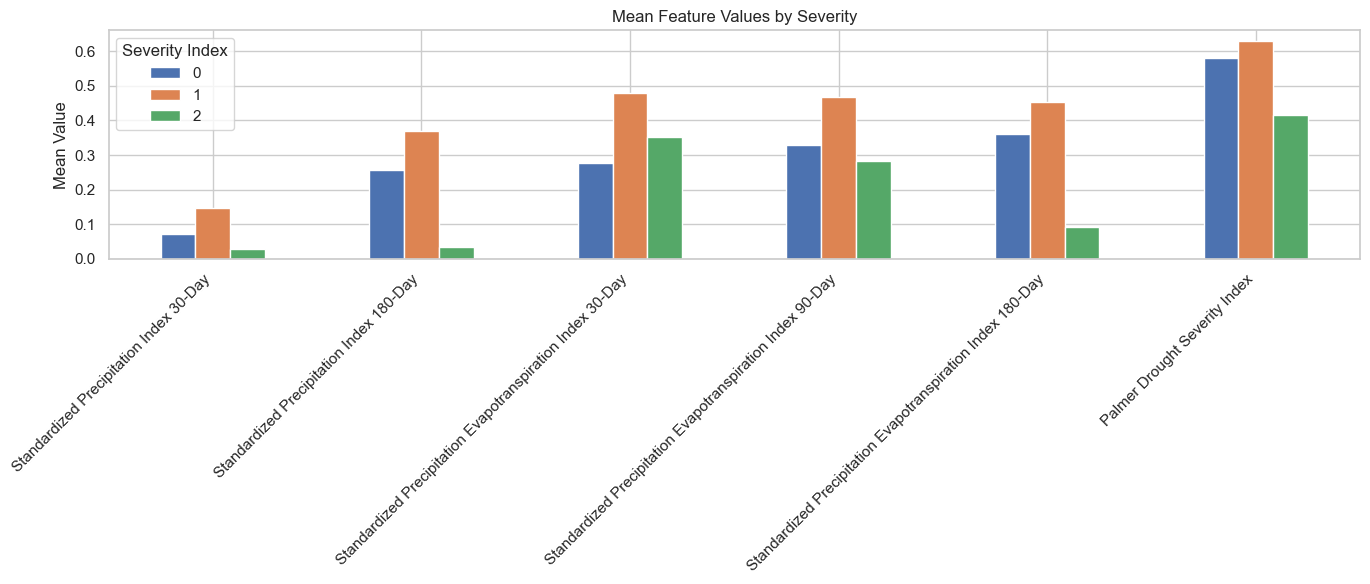

In [14]:
bar_group(filtered[water_supply_indexes])

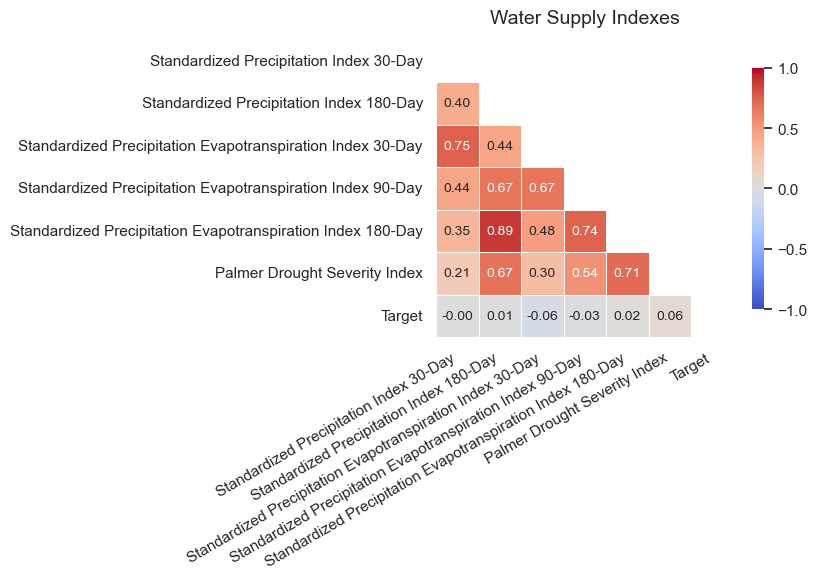

In [15]:
correlation_map(filtered[water_supply_indexes],'Water Supply Indexes')

## 5. Fire Danger

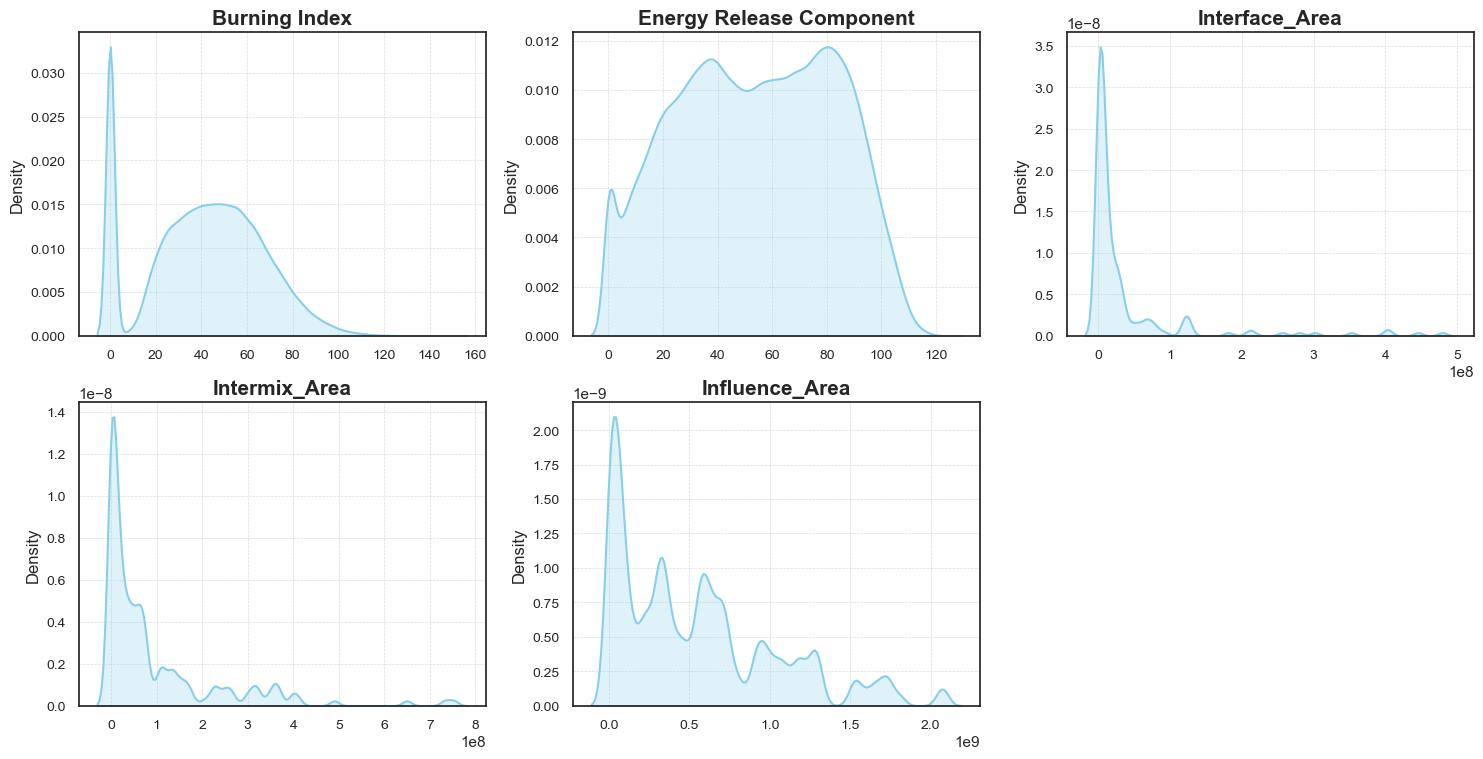

In [16]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Interface_Area', 
    'Intermix_Area', 
    'Influence_Area',
    'Target']

grid_kde(filtered[fire_danger].drop(columns='Target'))

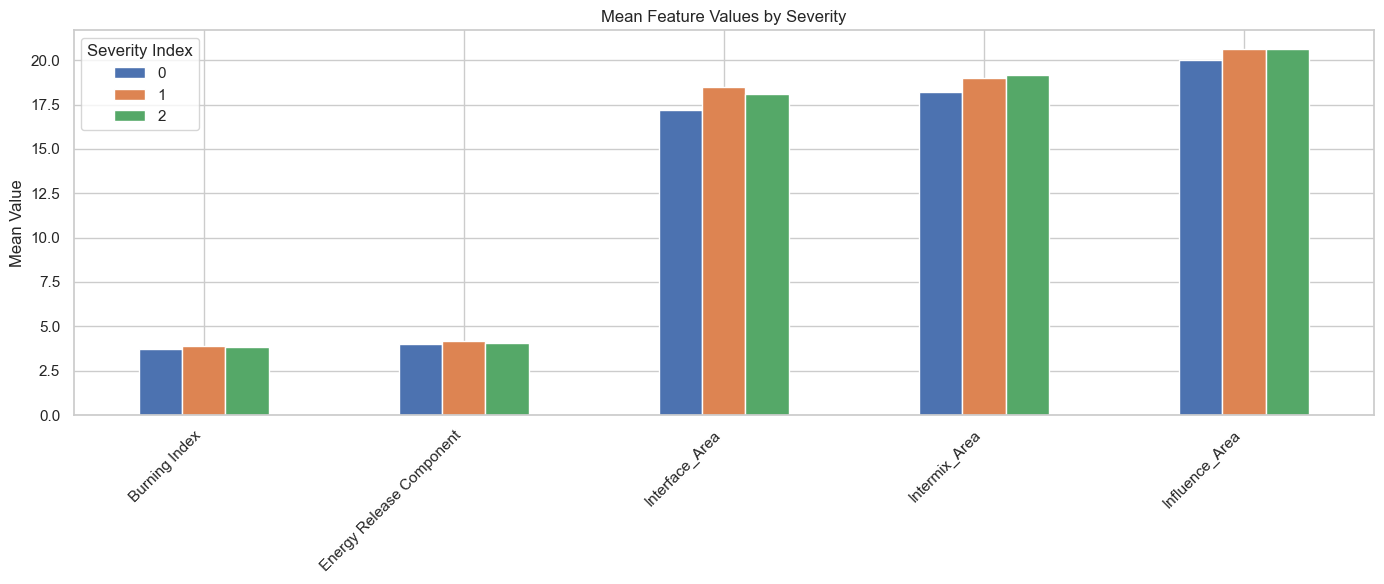

In [17]:
bar_group(filtered[fire_danger])

In [ ]:
correlation_map(filtered[fire_danger],'Fire Danger Variables')

## 6. Social Variables

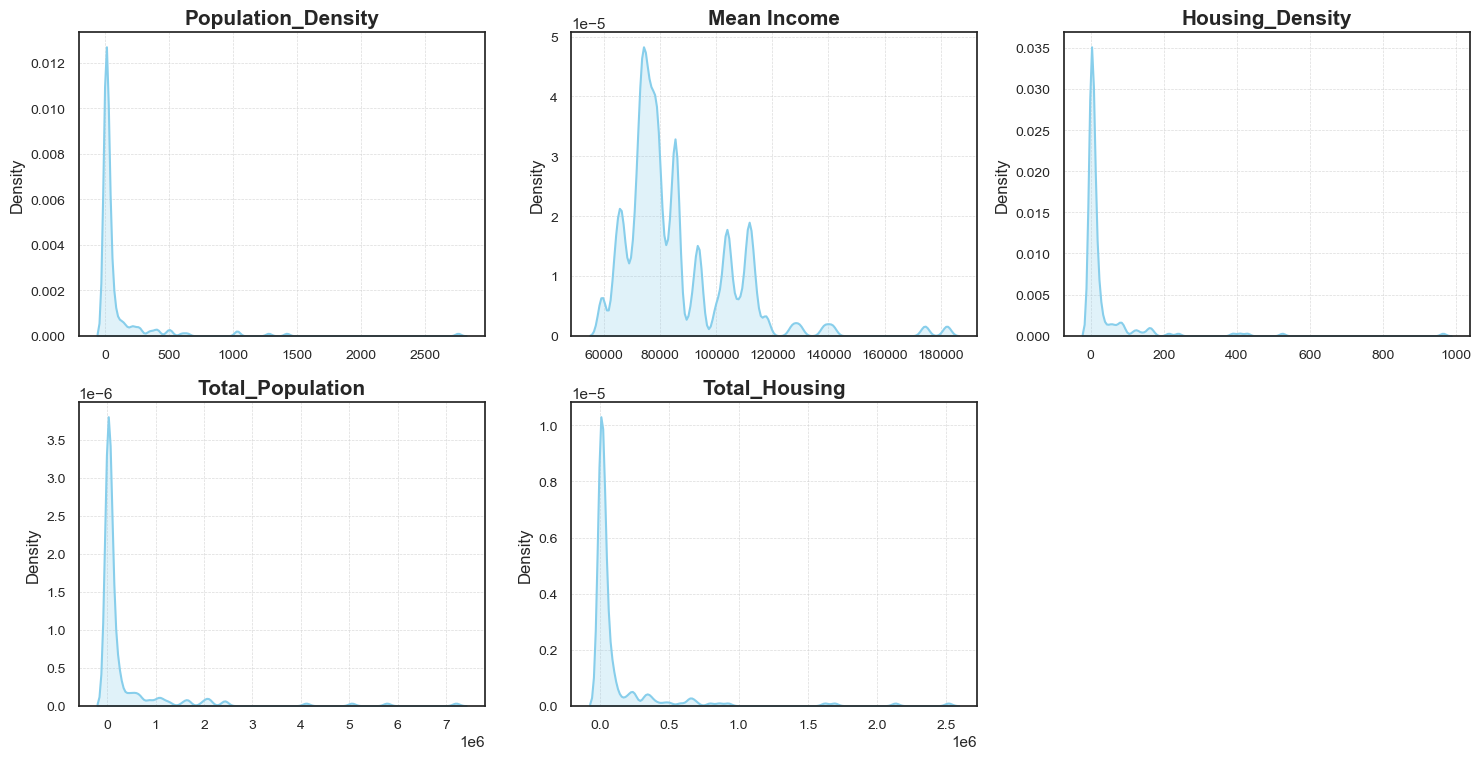

In [19]:
Population = ['Population_Density', 'Mean Income', 'Housing_Density',
              'Total_Population','Total_Housing',
          'Target']
grid_kde(filtered[Population].drop(columns='Target'))

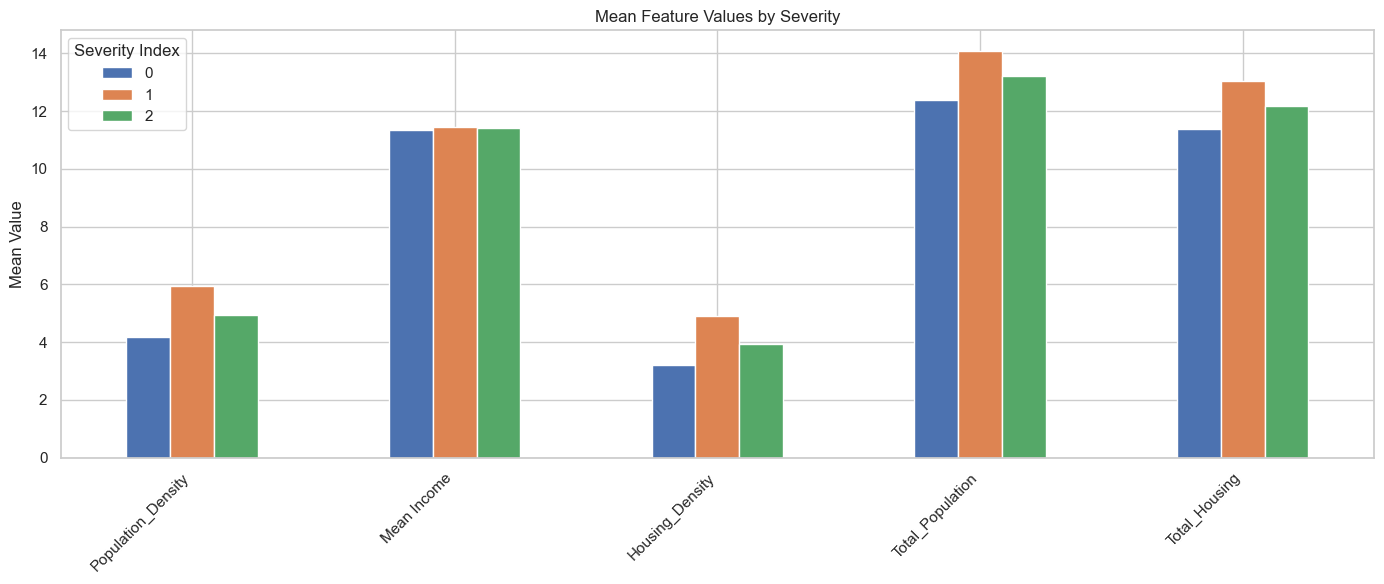

In [20]:
bar_group(filtered[Population])

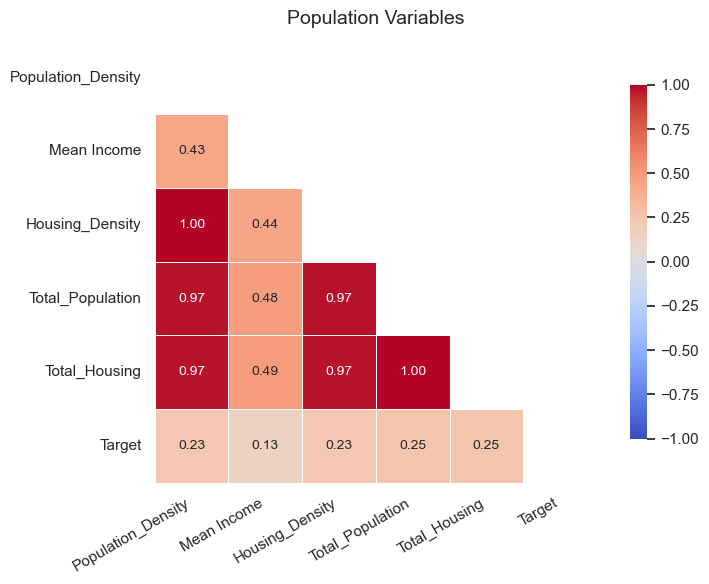

In [21]:
correlation_map(filtered[Population],'Population Variables')

## 7. Temporal Variables

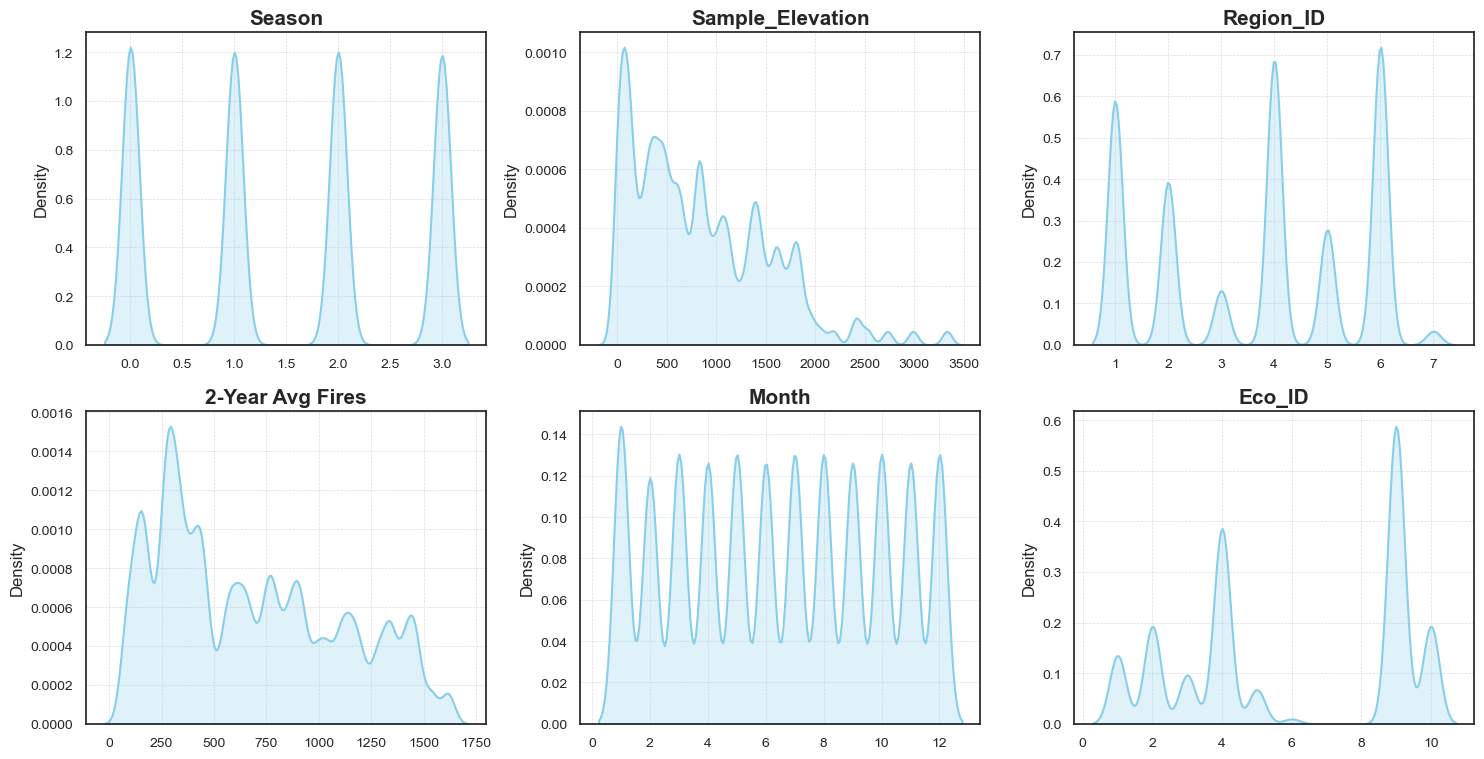

In [22]:
Temp = ['Season','Sample_Elevation','Region_ID','2-Year Avg Fires','Month',
         'Eco_ID','Target']
grid_kde(filtered[Temp].drop(columns='Target'))

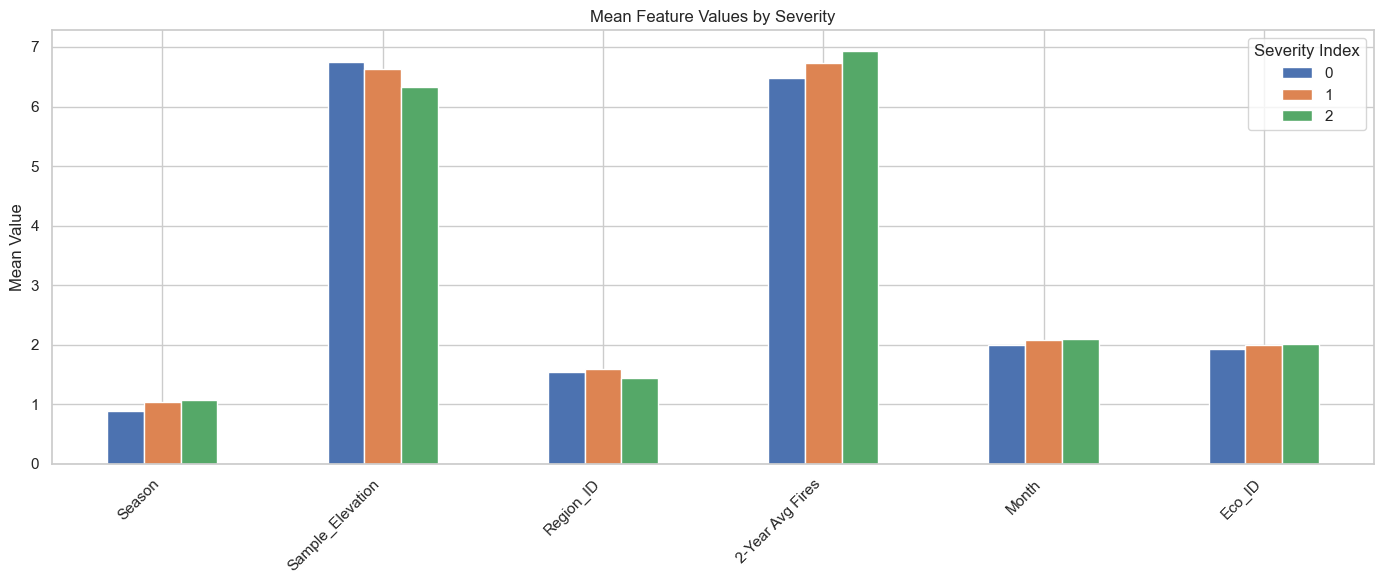

In [23]:
bar_group(filtered[Temp])

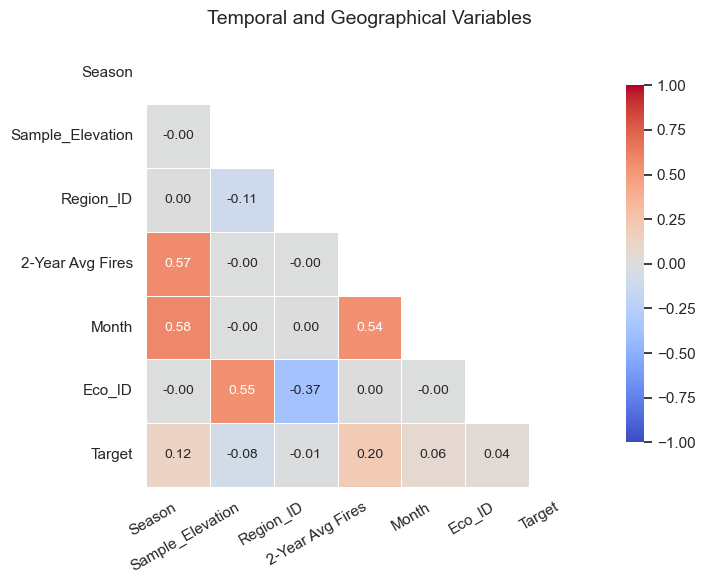

In [24]:
correlation_map(filtered[Temp],'Temporal and Geographical Variables')

---

## 8. Export File

In [26]:
filtered.to_csv('../data/processed/filtered.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
